# Naivní Bayesův klasifikátor

In [1]:
## load and split data
import pandas as pd
from sklearn.model_selection import train_test_split
from data_cleaner import preprocess_features

df_pos = pd.read_csv('../../data/inputs/clf_descriptors_positive_staphylococcus.csv')
df_neg = pd.read_csv('../../data/inputs/clf_descriptors_negative_02_dataset.csv')

#concat
df = pd.concat([df_pos, df_neg])

#split - "ACTIVITY" column is the target
X = df.drop(columns=['SEQUENCE','ACTIVITY'])
y = df['ACTIVITY']
X = preprocess_features(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

-----Variance treshold-----
Features dropped: Index([], dtype='object')
New shape: (884, 102)

-----Correlation filter-----
Features dropped: ['PP1', 'F2', 'F3', 'F4', 'KF1', 'KF2', 'KF4', 'MSWHIM1', 'MSWHIM3', 'E1', 'E2', 'E5', 'PD1', 'PD2', 'PRIN1', 'PRIN2', 'ProtFP1', 'ProtFP2', 'SV2', 'SV3', 'ST1', 'ST6', 'SVGER1', 'SVGER7', 'SVGER10', 'T1', 'T4', 'T5', 'VHSE1', 'VHSE2', 'VHSE3', 'VHSE5', 'VSTPV1', 'VSTPV2', 'VSTPV3', 'Z1', 'Z2', 'Z4']
New shape: (884, 64)

-----Filter by name-----
Features dropped: ['BLOSUM1', 'BLOSUM2', 'BLOSUM3', 'BLOSUM4', 'BLOSUM5', 'BLOSUM6', 'BLOSUM7', 'BLOSUM8', 'BLOSUM9', 'BLOSUM10']
New shape: (884, 54)


In [2]:
## Naive Bayes
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87        84
           1       0.89      0.86      0.87        93

    accuracy                           0.87       177
   macro avg       0.87      0.87      0.87       177
weighted avg       0.87      0.87      0.87       177

Precision: 0.8888888888888888
Recall: 0.8602150537634409
ROC AUC: 0.870583717357911

Confusion Matrix:
[[74 10]
 [13 80]]


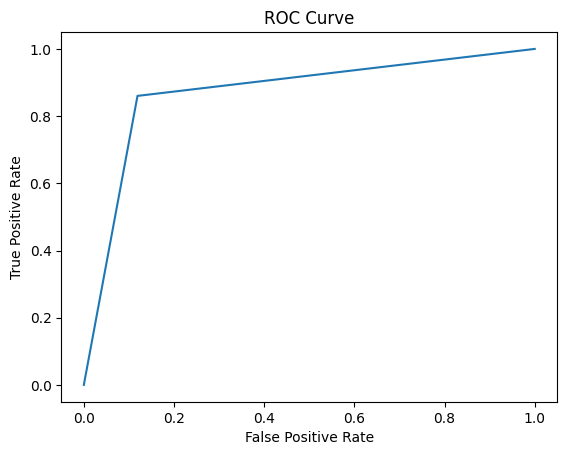

In [3]:
## Evaluation
from sklearn.metrics import precision_score, recall_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix

model = gnb
y_pred = model.predict(X_test)
print(f'Classification report:\n{classification_report(y_test, y_pred)}')

# precision, recall, f1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'ROC AUC: {roc_auc}')

# confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# plot ROC curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()